In [7]:
import json
import math
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from scipy.stats import kurtosis, normaltest, skew

warnings.filterwarnings("ignore", category=RuntimeWarning)


def load_table(path: str) -> pd.DataFrame:
    """
    统一读表：
    - csv -> read_csv(low_memory=False)
    - 其他 -> read_excel(openpyxl)
    """
    p = str(path).lower()
    if p.endswith(".csv"):
        return pd.read_csv(path, low_memory=False)
    return pd.read_excel(path, engine="openpyxl")


def normalize_judge(s: pd.Series) -> pd.Series:
    """
    Judge 归一化：
    - 兼容 BEST/BSET，统一映射到 BSET
    - 其余 PASS、MEDIUM 保持不变
    """
    x = s.astype(str).str.strip().str.upper()
    x = x.replace({"BEST": "BSET", "BSET": "BSET", "PASS": "PASS", "MEDIUM": "MEDIUM"})
    return x


def compute_stats(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    按列计算 q1, median, q3, std
    """
    q = np.nanpercentile(X, [25, 50, 75], axis=0)
    q1, med, q3 = q[0], q[1], q[2]
    std = np.nanstd(X, axis=0, ddof=1)
    std = np.nan_to_num(std, nan=0.0, posinf=0.0, neginf=0.0)
    return q1, med, q3, std


class BimodalityDetector:
    """
    双峰检测器：
    - 常规模式用于全列约束
    - 严格模式用于 FC 列优先场景（更容易识别葫芦型/中间凹陷）
    """

    def __init__(
        self,
        min_n: int = 30,
        peak_height_ratio: float = 0.10,
        sep_ratio: float = 0.08,
        valley_ratio: float = 0.78,
        min_side_mass: float = 0.12,
        fc_peak_height_ratio: float = 0.06,
        fc_sep_ratio: float = 0.05,
        fc_valley_ratio: float = 0.92,
        fc_min_side_mass: float = 0.08,
    ):
        self.min_n = min_n

        self.cfg_std = {
            "peak_height_ratio": peak_height_ratio,
            "sep_ratio": sep_ratio,
            "valley_ratio": valley_ratio,
            "min_side_mass": min_side_mass,
        }
        self.cfg_fc = {
            "peak_height_ratio": fc_peak_height_ratio,
            "sep_ratio": fc_sep_ratio,
            "valley_ratio": fc_valley_ratio,
            "min_side_mass": fc_min_side_mass,
        }

    @staticmethod
    def _check_core(y: np.ndarray, min_n: int, cfg: Dict[str, float]) -> bool:
        """
        核心双峰判定逻辑（直方图 + 平滑 + 峰谷结构）
        """
        x = np.asarray(y, dtype=np.float64)
        x = x[np.isfinite(x)]
        n = x.size
        if n < min_n:
            return False

        x_min = float(np.min(x))
        x_max = float(np.max(x))
        if (not np.isfinite(x_min)) or (not np.isfinite(x_max)) or (x_max <= x_min):
            return False

        # bin 数量随样本量变化，避免过粗或过细
        bins = int(np.clip(np.sqrt(n), 12, 48))
        hist, edges = np.histogram(x, bins=bins)
        if hist.max() <= 0:
            return False

        # 轻量平滑，降低噪声峰
        smooth = np.convolve(hist.astype(np.float64), np.array([1.0, 2.0, 1.0]), mode="same")
        thr = cfg["peak_height_ratio"] * float(np.max(smooth))

        left = smooth[:-2]
        mid = smooth[1:-1]
        right = smooth[2:]
        peak_idx = np.where((mid > left) & (mid >= right) & (mid >= thr))[0] + 1
        if peak_idx.size < 2:
            return False

        # 取最高两峰
        top2 = peak_idx[np.argsort(smooth[peak_idx])[-2:]]
        p1, p2 = int(min(top2)), int(max(top2))

        centers = 0.5 * (edges[:-1] + edges[1:])
        sep = abs(centers[p1] - centers[p2]) / (x_max - x_min + 1e-12)
        if sep < cfg["sep_ratio"]:
            return False

        # 峰间谷深
        valley_pos = p1 + int(np.argmin(smooth[p1:p2 + 1]))
        valley = float(smooth[valley_pos])
        min_peak = float(min(smooth[p1], smooth[p2])) + 1e-12
        if valley > cfg["valley_ratio"] * min_peak:
            return False

        # 谷点左右质量，避免一个主峰 + 少量噪声的误判
        left_mass = float(hist[:valley_pos + 1].sum()) / max(1, n)
        right_mass = float(hist[valley_pos + 1:].sum()) / max(1, n)
        if min(left_mass, right_mass) < cfg["min_side_mass"]:
            return False

        return True

    def is_bimodal(self, y: np.ndarray, strict_fc: bool = False) -> bool:
        cfg = self.cfg_fc if strict_fc else self.cfg_std
        return self._check_core(y=y, min_n=self.min_n, cfg=cfg)


class ConstrainedSubsetSampler:
    """
    约束优化抽样器

    主要功能：
    1) 从 df_C 抽样，逼近 df_C30
    2) 强制 Judge 比例
    3) 全 93 列禁双峰
    4) 目标列分布/统计量相似
    5) FC 列正态偏好，且可选 FC 优先严格模式
    6) 离群值与尾部覆盖约束
    """

    def __init__(
        self,
        mode: str = "A",                      # A: 全 93 列优化；B: 仅 FC 列优化
        prioritize_fc: bool = False,          # 是否更看重 FC 列
        preferred_size: Tuple[int, int] = (320, 340),
        target_size: int = 330,
        size_relax_margin: int = 120,         # 当 preferred 不可行时，向两侧扩展搜索范围
        # Judge 比例约束
        bset_range: Tuple[float, float] = (0.45, 0.50),
        pass_range: Tuple[float, float] = (0.42, 0.47),
        medium_range: Tuple[float, float] = (0.07, 0.09),
        # 统计约束
        stat_threshold: float = 3.0,          # q1/median/q3/std 绝对差值理想阈值
        # 搜索参数
        n_starts: int = 5,
        max_iter: int = 900,
        early_stop: int = 220,
        init_temp: float = 0.08,
        cooling: float = 0.997,
        # 权重（软约束）
        w_stat: float = 1.0,
        w_shape: float = 1.2,
        w_tail_width: float = 1.2,
        w_outlier: float = 2.5,
        w_extreme: float = 8.0,
        w_tail_cut: float = 2.0,
        w_norm: float = 0.6,
        w_stat_violation: float = 0.2,
        w_size_relax: float = 25.0,           # 样本量落出 preferred 后的惩罚强度
        # FC 相关
        fc_weight_mult: float = 2.5,          # FC 列在统计/形态/尾部等项的加权倍数
        normal_skew_thr: float = 0.5,
        normal_kurt_thr: float = 1.5,
        fc_normal_skew_thr: float = 0.30,
        fc_normal_kurt_thr: float = 0.80,
        fc_norm_weight_mult: float = 2.5,
        fc_norm_hard_margin: float = 0.20,    # FC 正态硬违规阈值增量
        # 尾部截断硬阈值（归一化缺口）
        tail_cut_hard_thr: float = 0.60,
        # 计划搜索规模
        max_pref_plans: int = 8,
        max_relaxed_plans: int = 8,
        # 随机种子
        random_seed: int = 42,
    ):
        if mode not in ("A", "B"):
            raise ValueError("mode 只能是 A 或 B。")

        self.mode = mode
        self.prioritize_fc = prioritize_fc

        self.pref_low, self.pref_high = preferred_size
        self.target_size = target_size
        self.size_relax_margin = size_relax_margin

        self.bset_range = bset_range
        self.pass_range = pass_range
        self.medium_range = medium_range

        self.stat_threshold = stat_threshold

        self.n_starts = n_starts
        self.max_iter = max_iter
        self.early_stop = early_stop
        self.init_temp = init_temp
        self.cooling = cooling

        self.w_stat = w_stat
        self.w_shape = w_shape
        self.w_tail_width = w_tail_width
        self.w_outlier = w_outlier
        self.w_extreme = w_extreme
        self.w_tail_cut = w_tail_cut
        self.w_norm = w_norm
        self.w_stat_violation = w_stat_violation
        self.w_size_relax = w_size_relax

        self.fc_weight_mult = fc_weight_mult
        self.normal_skew_thr = normal_skew_thr
        self.normal_kurt_thr = normal_kurt_thr
        self.fc_normal_skew_thr = fc_normal_skew_thr
        self.fc_normal_kurt_thr = fc_normal_kurt_thr
        self.fc_norm_weight_mult = fc_norm_weight_mult
        self.fc_norm_hard_margin = fc_norm_hard_margin

        self.tail_cut_hard_thr = tail_cut_hard_thr

        self.max_pref_plans = max_pref_plans
        self.max_relaxed_plans = max_relaxed_plans

        self.rng = np.random.default_rng(random_seed)
        np.random.seed(random_seed)

        # 分位点网格，用于形态相似度
        self.shape_q = np.array([5, 15, 25, 35, 50, 65, 75, 85, 95], dtype=np.float64)

        # 双峰检测器
        self.bimodal_detector = BimodalityDetector()

        # 运行时变量
        self.df_c = None
        self.df_ref = None

        self.all_cols = None
        self.fc_cols = None
        self.target_cols = None

        self.X_c_93 = None
        self.X_ref_93 = None

        self.n_rows = 0
        self.n_cols = 0

        self.target_pos = None
        self.fc_pos = None
        self.fc_pos_set = None

        self.judge_code = None
        self.pools = None  # {0: BSET idx, 1: PASS idx, 2: MEDIUM idx}

        # 目标列参考统计
        self.ref_q1_t = None
        self.ref_med_t = None
        self.ref_q3_t = None
        self.ref_std_t = None
        self.ref_shape_t = None
        self.ref_scale_t = None
        self.ref_bimodal_t = None

        # 目标列尾部/异常率参考
        self.ref_p01_t = None
        self.ref_p99_t = None
        self.ref_tail_scale_t = None
        self.ref_low15_t = None
        self.ref_up15_t = None
        self.ref_low30_t = None
        self.ref_up30_t = None
        self.ref_out15_t = None
        self.ref_out30_t = None

        # 全 93 列参考
        self.ref_q1_all = None
        self.ref_med_all = None
        self.ref_q3_all = None
        self.ref_std_all = None
        self.ref_shape_all = None
        self.ref_scale_all = None
        self.ref_bimodal_all = None

        self.ref_p01_all = None
        self.ref_p99_all = None
        self.ref_range_scale_all = None
        self.ref_low15_all = None
        self.ref_up15_all = None
        self.ref_low30_all = None
        self.ref_up30_all = None
        self.ref_out15_all = None
        self.ref_out30_all = None

        # 目标列权重
        self.target_weights = None

        # 样本计划
        self.plans = None
        self.preferred_feasible = False

    @staticmethod
    def _extract_93_columns(df: pd.DataFrame) -> List[str]:
        """
        优先按 EFL 起点提取 93 列；若 EFL 不存在则回退到去除非目标字段后的前 93 列
        """
        if "EFL" in df.columns:
            start = df.columns.get_loc("EFL")
            cols = list(df.columns[start:start + 93])
            if len(cols) != 93:
                raise ValueError(f"从 EFL 开始不足 93 列，实际只有 {len(cols)}。")
            return cols

        # 回退策略
        skip = {"Judge", "#", "__orig_index__"}
        cand = [c for c in df.columns if c not in skip]
        if len(cand) < 93:
            raise ValueError("未找到 EFL，且可用列不足 93。")
        return cand[:93]

    def _prepare(self, df_c: pd.DataFrame, df_ref: pd.DataFrame) -> None:
        """
        预处理：
        1) 列选择
        2) Judge 归一化
        3) numpy 矩阵化
        4) 参考统计预计算
        5) 可行样本计划生成
        """
        self.df_c = df_c.copy()
        self.df_ref = df_ref.copy()

        # 1) 目标列
        self.all_cols = self._extract_93_columns(self.df_ref)
        self.n_cols = len(self.all_cols)

        missing = [c for c in self.all_cols if c not in self.df_c.columns]
        if missing:
            raise ValueError(f"df_C 缺少目标列，示例缺失：{missing[:5]}")

        self.fc_cols = [c for c in self.all_cols if str(c).startswith("FC")]
        if self.mode == "A":
            self.target_cols = list(self.all_cols)
        else:
            self.target_cols = list(self.fc_cols)
            if len(self.target_cols) == 0:
                raise ValueError("mode=B 但未找到 FC 列。")

        # 2) Judge 归一化
        if "Judge" not in self.df_c.columns:
            raise ValueError("df_C 缺少 Judge 列。")
        if "Judge" not in self.df_ref.columns:
            raise ValueError("df_C30 缺少 Judge 列。")

        self.df_c["Judge"] = normalize_judge(self.df_c["Judge"])
        self.df_ref["Judge"] = normalize_judge(self.df_ref["Judge"])

        valid = {"BSET", "PASS", "MEDIUM"}

        # 只对候选集 df_c 进行 Judge 过滤（这是硬约束对象）
        raw_c = self.df_c["Judge"].astype(str).value_counts(dropna=False)
        self.df_c = self.df_c[self.df_c["Judge"].isin(valid)].copy()
        if self.df_c.empty:
            raise ValueError(f"df_C 在 Judge 过滤后为空。Judge 取值示例: {raw_c.head(10).to_dict()}")

        # 注意：不再对 df_ref 按 Judge 过滤
        # 参考集只用于 93 列分布对齐；其 Judge 不参与硬约束
        if self.df_ref.empty:
            raise ValueError("df_C30 参考组为空，请检查 # 过滤条件。")

        if not self.df_ref["Judge"].isin(valid).any():
            print("[Warning] df_C30 当前参考组的 Judge 不在 BSET/PASS/MEDIUM 中，已忽略其 Judge 过滤，仅使用 93 列分布做参考。")

        # 保存原始索引（后续输出 selected_indices 要用）
        self.df_c = self.df_c.copy()
        self.df_c["__orig_index__"] = self.df_c.index.to_numpy(dtype=np.int64)
        self.df_c = self.df_c.reset_index(drop=True)

        # 3) 数值矩阵
        self.X_c_93 = (
            self.df_c[self.all_cols]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=np.float32)
        )
        self.X_ref_93 = (
            self.df_ref[self.all_cols]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=np.float32)
        )
        self.n_rows = self.X_c_93.shape[0]

        col_to_pos = {c: i for i, c in enumerate(self.all_cols)}
        self.target_pos = np.array([col_to_pos[c] for c in self.target_cols], dtype=np.int32)
        self.fc_pos = np.array([col_to_pos[c] for c in self.fc_cols], dtype=np.int32)
        self.fc_pos_set = set(self.fc_pos.tolist())

        # Judge 编码
        code_map = {"BSET": 0, "PASS": 1, "MEDIUM": 2}
        self.judge_code = self.df_c["Judge"].map(code_map).to_numpy(dtype=np.int8)
        self.pools = {j: np.where(self.judge_code == j)[0] for j in (0, 1, 2)}

        # 4) 参考统计预计算（目标列）
        X_ref_t = self.X_ref_93[:, self.target_pos]
        self.ref_q1_t, self.ref_med_t, self.ref_q3_t, self.ref_std_t = compute_stats(X_ref_t)
        self.ref_shape_t = np.nanpercentile(X_ref_t, self.shape_q, axis=0)

        iqr_t = self.ref_q3_t - self.ref_q1_t
        self.ref_scale_t = np.where(
            iqr_t > 1e-6,
            iqr_t,
            np.where(self.ref_std_t > 1e-6, self.ref_std_t, 1.0),
        )

        self.ref_bimodal_t = np.array(
            [self.bimodal_detector.is_bimodal(X_ref_t[:, i], strict_fc=False) for i in range(X_ref_t.shape[1])],
            dtype=bool,
        )

        self.ref_p01_t = np.nanpercentile(X_ref_t, 1, axis=0)
        self.ref_p99_t = np.nanpercentile(X_ref_t, 99, axis=0)
        tail_span_t = self.ref_p99_t - self.ref_p01_t
        self.ref_tail_scale_t = np.where(
            tail_span_t > 1e-6,
            tail_span_t,
            np.where(iqr_t > 1e-6, iqr_t, np.where(self.ref_std_t > 1e-6, self.ref_std_t, 1.0)),
        )

        iqr_safe_t = np.where(
            iqr_t > 1e-6,
            iqr_t,
            np.where(self.ref_std_t > 1e-6, self.ref_std_t, 1.0),
        )
        self.ref_low15_t = self.ref_q1_t - 1.5 * iqr_safe_t
        self.ref_up15_t = self.ref_q3_t + 1.5 * iqr_safe_t
        self.ref_low30_t = self.ref_q1_t - 3.0 * iqr_safe_t
        self.ref_up30_t = self.ref_q3_t + 3.0 * iqr_safe_t

        ref_out15_t = (X_ref_t < self.ref_low15_t) | (X_ref_t > self.ref_up15_t)
        ref_out30_t = (X_ref_t < self.ref_low30_t) | (X_ref_t > self.ref_up30_t)
        self.ref_out15_t = np.nan_to_num(np.nanmean(ref_out15_t, axis=0), nan=0.0, posinf=0.0, neginf=0.0)
        self.ref_out30_t = np.nan_to_num(np.nanmean(ref_out30_t, axis=0), nan=0.0, posinf=0.0, neginf=0.0)

        # 目标列权重（FC 优先时 FC 列加权）
        target_is_fc = np.isin(self.target_pos, self.fc_pos)
        if self.prioritize_fc:
            self.target_weights = np.where(target_is_fc, self.fc_weight_mult, 1.0).astype(np.float64)
        else:
            self.target_weights = np.ones(self.target_pos.shape[0], dtype=np.float64)

        # 参考统计预计算（全 93 列）
        self.ref_q1_all, self.ref_med_all, self.ref_q3_all, self.ref_std_all = compute_stats(self.X_ref_93)
        self.ref_shape_all = np.nanpercentile(self.X_ref_93, self.shape_q, axis=0)

        iqr_all = self.ref_q3_all - self.ref_q1_all
        self.ref_scale_all = np.where(
            iqr_all > 1e-6,
            iqr_all,
            np.where(self.ref_std_all > 1e-6, self.ref_std_all, 1.0),
        )

        self.ref_bimodal_all = np.array(
            [self.bimodal_detector.is_bimodal(self.X_ref_93[:, j], strict_fc=False) for j in range(self.n_cols)],
            dtype=bool,
        )

        self.ref_p01_all = np.nanpercentile(self.X_ref_93, 1, axis=0)
        self.ref_p99_all = np.nanpercentile(self.X_ref_93, 99, axis=0)
        span_all = self.ref_p99_all - self.ref_p01_all
        self.ref_range_scale_all = np.where(
            span_all > 1e-6,
            span_all,
            np.where(iqr_all > 1e-6, iqr_all, np.where(self.ref_std_all > 1e-6, self.ref_std_all, 1.0)),
        )

        iqr_safe_all = np.where(
            iqr_all > 1e-6,
            iqr_all,
            np.where(self.ref_std_all > 1e-6, self.ref_std_all, 1.0),
        )
        self.ref_low15_all = self.ref_q1_all - 1.5 * iqr_safe_all
        self.ref_up15_all = self.ref_q3_all + 1.5 * iqr_safe_all
        self.ref_low30_all = self.ref_q1_all - 3.0 * iqr_safe_all
        self.ref_up30_all = self.ref_q3_all + 3.0 * iqr_safe_all

        ref_out15_all = (self.X_ref_93 < self.ref_low15_all) | (self.X_ref_93 > self.ref_up15_all)
        ref_out30_all = (self.X_ref_93 < self.ref_low30_all) | (self.X_ref_93 > self.ref_up30_all)
        self.ref_out15_all = np.nan_to_num(np.nanmean(ref_out15_all, axis=0), nan=0.0, posinf=0.0, neginf=0.0)
        self.ref_out30_all = np.nan_to_num(np.nanmean(ref_out30_all, axis=0), nan=0.0, posinf=0.0, neginf=0.0)

        # 5) 可行样本计划
        self.plans = self._build_plans()
        self.preferred_feasible = any(p["in_preferred"] for p in self.plans)

    def _best_counts_for_n(self, n: int, avail: Dict[int, int]):
        """
        给定样本量 n，求满足 Judge 比例约束的最佳计数组合
        """
        b_lo, b_hi = math.ceil(self.bset_range[0] * n), math.floor(self.bset_range[1] * n)
        p_lo, p_hi = math.ceil(self.pass_range[0] * n), math.floor(self.pass_range[1] * n)
        m_lo, m_hi = math.ceil(self.medium_range[0] * n), math.floor(self.medium_range[1] * n)

        if b_lo > b_hi or p_lo > p_hi or m_lo > m_hi:
            return None

        best = None
        for nb in range(b_lo, b_hi + 1):
            if nb > avail[0]:
                continue
            for npa in range(p_lo, p_hi + 1):
                if npa > avail[1]:
                    continue
                nm = n - nb - npa
                if nm < m_lo or nm > m_hi:
                    continue
                if nm > avail[2]:
                    continue

                # 越接近 47.5/44.5/8 越好
                dev = abs(nb / n - 0.475) + abs(npa / n - 0.445) + abs(nm / n - 0.08)
                cand = (dev, {0: nb, 1: npa, 2: nm})
                if (best is None) or (cand[0] < best[0]):
                    best = cand
        return best

    def _build_plans(self) -> List[Dict]:
        """
        构造样本量计划：
        - 优先 preferred_size
        - 若无解，向两侧扩展
        """
        avail = {0: len(self.pools[0]), 1: len(self.pools[1]), 2: len(self.pools[2])}

        low = max(50, self.pref_low - self.size_relax_margin)
        high = min(self.n_rows, self.pref_high + self.size_relax_margin)
        if low > high:
            low, high = 50, self.n_rows

        plans = []
        for n in range(low, high + 1):
            best = self._best_counts_for_n(n, avail)
            if best is None:
                continue

            ratio_dev, counts = best
            in_pref = self.pref_low <= n <= self.pref_high
            dist_pref = 0 if in_pref else min(abs(n - self.pref_low), abs(n - self.pref_high))

            plans.append(
                {
                    "n": n,
                    "counts": counts,
                    "ratio_dev": ratio_dev,
                    "in_preferred": in_pref,
                    "dist_pref": dist_pref,
                }
            )

        if len(plans) == 0:
            raise ValueError("在可搜索样本量区间内找不到满足 Judge 比例约束的可行解。")

        plans.sort(
            key=lambda p: (
                0 if p["in_preferred"] else 1,
                p["dist_pref"],
                abs(p["n"] - self.target_size),
                p["ratio_dev"],
            )
        )
        return plans

    def _judge_ok(self, cnt: np.ndarray, n: int):
        """
        Judge 约束检查
        """
        b = cnt[0] / n
        p = cnt[1] / n
        m = cnt[2] / n

        ok = (
            self.bset_range[0] <= b <= self.bset_range[1]
            and self.pass_range[0] <= p <= self.pass_range[1]
            and self.medium_range[0] <= m <= self.medium_range[1]
        )

        dev = (
            max(0.0, self.bset_range[0] - b, b - self.bset_range[1])
            + max(0.0, self.pass_range[0] - p, p - self.pass_range[1])
            + max(0.0, self.medium_range[0] - m, m - self.medium_range[1])
        )
        return ok, (b, p, m), dev

    def _sample_initial_indices(self, plan: Dict) -> np.ndarray:
        """
        根据计划 counts 随机初始化
        """
        nb = plan["counts"][0]
        npa = plan["counts"][1]
        nm = plan["counts"][2]

        idx_b = self.rng.choice(self.pools[0], size=nb, replace=False) if nb > 0 else np.array([], dtype=int)
        idx_p = self.rng.choice(self.pools[1], size=npa, replace=False) if npa > 0 else np.array([], dtype=int)
        idx_m = self.rng.choice(self.pools[2], size=nm, replace=False) if nm > 0 else np.array([], dtype=int)

        idx = np.concatenate([idx_b, idx_p, idx_m])
        self.rng.shuffle(idx)
        return idx

    def _propose_swap(self, selected: np.ndarray):
        """
        同 Judge 类别交换，保证 Judge 比例不变
        """
        valid_j = []
        for j in (0, 1, 2):
            pool_j = self.pools[j]
            sel_n = int(np.count_nonzero(selected[pool_j]))
            unsel_n = int(pool_j.size - sel_n)
            if sel_n > 0 and unsel_n > 0:
                valid_j.append(j)

        if len(valid_j) == 0:
            return None

        j = int(valid_j[self.rng.integers(0, len(valid_j))])
        pool_j = self.pools[j]

        selected_j = pool_j[selected[pool_j]]
        unselected_j = pool_j[~selected[pool_j]]

        out_i = int(selected_j[self.rng.integers(0, selected_j.size)])
        in_i = int(unselected_j[self.rng.integers(0, unselected_j.size)])

        selected[out_i] = False
        selected[in_i] = True
        return out_i, in_i

    @staticmethod
    def _fc_normality_metrics(X_fc: np.ndarray):
        """
        计算 FC 列正态指标：
        - skew
        - kurtosis (Pearson, 正态理论值约 3)
        - normaltest pvalue（样本足够时）
        """
        if X_fc.size == 0:
            return np.array([]), np.array([]), np.array([])

        sk = skew(X_fc, axis=0, bias=False, nan_policy="omit")
        ku = kurtosis(X_fc, axis=0, fisher=False, bias=False, nan_policy="omit")

        sk = np.asarray(sk, dtype=np.float64)
        ku = np.asarray(ku, dtype=np.float64)

        pvals = np.full(sk.shape, np.nan, dtype=np.float64)
        for i in range(X_fc.shape[1]):
            y = X_fc[:, i]
            y = y[np.isfinite(y)]
            if y.size >= 20:
                try:
                    pvals[i] = float(normaltest(y).pvalue)
                except Exception:
                    pvals[i] = np.nan

        return sk, ku, pvals

    def _evaluate(self, idx: np.ndarray, plan: Dict, detail: bool = False) -> Dict:
        """
        评估函数：
        返回 score、硬约束状态、关键诊断指标
        """
        n = idx.size
        X93 = self.X_c_93[idx, :]
        Xt = X93[:, self.target_pos]

        # ===== 目标列统计差 =====
        q = np.nanpercentile(Xt, [25, 50, 75], axis=0)
        q1, med, q3 = q[0], q[1], q[2]
        std = np.nanstd(Xt, axis=0, ddof=1)

        d_med = np.abs(med - self.ref_med_t)
        d_q1 = np.abs(q1 - self.ref_q1_t)
        d_q3 = np.abs(q3 - self.ref_q3_t)
        d_std = np.abs(std - self.ref_std_t)

        d_med = np.nan_to_num(d_med, nan=1e3, posinf=1e3, neginf=1e3)
        d_q1 = np.nan_to_num(d_q1, nan=1e3, posinf=1e3, neginf=1e3)
        d_q3 = np.nan_to_num(d_q3, nan=1e3, posinf=1e3, neginf=1e3)
        d_std = np.nan_to_num(d_std, nan=1e3, posinf=1e3, neginf=1e3)

        d_stack = np.vstack([d_med, d_q1, d_q3, d_std])
        d_max = np.max(d_stack, axis=0)
        stat_violation = d_max > self.stat_threshold

        stat_pen_each = np.mean(d_stack, axis=0)
        stat_penalty = float(np.average(stat_pen_each, weights=self.target_weights))
        stat_violation_rate = float(np.average(stat_violation.astype(np.float64), weights=self.target_weights))

        # ===== 目标列形态差（参考双峰列可豁免形态）=====
        sub_shape = np.nanpercentile(Xt, self.shape_q, axis=0)
        shape_each = np.mean(
            np.abs(sub_shape - self.ref_shape_t) / (self.ref_scale_t + 1e-6),
            axis=0,
        )
        shape_each = np.nan_to_num(shape_each, nan=1e3, posinf=1e3, neginf=1e3)

        # 参考若为双峰，只要求统计量接近，不要求形态相似
        shape_each[self.ref_bimodal_t] = 0.0
        shape_penalty = float(np.average(shape_each, weights=self.target_weights))

        # ===== 目标列尾部宽度 + 异常值 =====
        p01_t = np.nanpercentile(Xt, 1, axis=0)
        p99_t = np.nanpercentile(Xt, 99, axis=0)
        tail_sub = p99_t - p01_t
        tail_ref = self.ref_p99_t - self.ref_p01_t
        tail_width_each = np.abs(tail_sub - tail_ref) / (self.ref_tail_scale_t + 1e-6)
        tail_width_each = np.nan_to_num(tail_width_each, nan=1e3, posinf=1e3, neginf=1e3)
        tail_width_penalty = float(np.average(tail_width_each, weights=self.target_weights))

        out15_t = (Xt < self.ref_low15_t) | (Xt > self.ref_up15_t)
        out30_t = (Xt < self.ref_low30_t) | (Xt > self.ref_up30_t)

        out15_rate_t = np.nan_to_num(np.nanmean(out15_t, axis=0), nan=0.0, posinf=0.0, neginf=0.0)
        out30_rate_t = np.nan_to_num(np.nanmean(out30_t, axis=0), nan=0.0, posinf=0.0, neginf=0.0)

        # 离群值既看与参考差异，也惩罚绝对离群率过高
        outlier_each = np.abs(out15_rate_t - self.ref_out15_t) + 0.5 * np.maximum(0.0, out15_rate_t - 0.01)
        outlier_penalty = float(np.average(outlier_each, weights=self.target_weights))

        # 极端点惩罚：3IQR 外比例高于参考 + margin
        extreme_each = np.maximum(0.0, out30_rate_t - (self.ref_out30_t + 0.01))
        extreme_penalty = float(np.average(extreme_each, weights=self.target_weights))

        # ===== FC 正态惩罚 =====
        fc_normality_penalty = 0.0
        fc_norm_hard_count = 0
        if self.fc_pos.size > 0:
            Xfc = X93[:, self.fc_pos]
            sk, ku, pvals = self._fc_normality_metrics(Xfc)

            sk = np.nan_to_num(sk, nan=10.0, posinf=10.0, neginf=10.0)
            ku = np.nan_to_num(ku, nan=10.0, posinf=10.0, neginf=10.0)
            p_safe = np.where(np.isfinite(pvals), pvals, 0.05)

            sk_thr = self.fc_normal_skew_thr if self.prioritize_fc else self.normal_skew_thr
            ku_thr = self.fc_normal_kurt_thr if self.prioritize_fc else self.normal_kurt_thr

            norm_each = (
                np.maximum(0.0, np.abs(sk) - sk_thr)
                + np.maximum(0.0, np.abs(ku - 3.0) - ku_thr)
                + np.maximum(0.0, 0.05 - p_safe) * 2.0
            )
            fc_normality_penalty = float(np.mean(norm_each))

            if self.prioritize_fc:
                fc_normality_penalty *= self.fc_norm_weight_mult
                hard_mask = (
                    (np.abs(sk) > (sk_thr + self.fc_norm_hard_margin))
                    | (np.abs(ku - 3.0) > (ku_thr + self.fc_norm_hard_margin))
                )
                fc_norm_hard_count = int(np.sum(hard_mask))

        # ===== 全 93 列双峰硬约束 =====
        bimodal_flags = np.zeros(self.n_cols, dtype=bool)
        for j in range(self.n_cols):
            strict_fc = self.prioritize_fc and (j in self.fc_pos_set)
            bimodal_flags[j] = self.bimodal_detector.is_bimodal(X93[:, j], strict_fc=strict_fc)

        bimodal_count = int(np.sum(bimodal_flags))
        fc_bimodal_count = int(np.sum(bimodal_flags[self.fc_pos])) if self.fc_pos.size > 0 else 0

        # ===== 尾部截断约束（全 93 列）=====
        sub_p01_all = np.nanpercentile(X93, 1, axis=0)
        sub_p99_all = np.nanpercentile(X93, 99, axis=0)

        left_cut = np.maximum(0.0, (sub_p01_all - self.ref_p01_all) / (self.ref_range_scale_all + 1e-6))
        right_cut = np.maximum(0.0, (self.ref_p99_all - sub_p99_all) / (self.ref_range_scale_all + 1e-6))
        tail_cut_each = left_cut + right_cut
        tail_cut_each = np.nan_to_num(tail_cut_each, nan=0.0, posinf=1e3, neginf=0.0)

        tail_cut_penalty = float(np.mean(tail_cut_each))
        tail_cut_hard_count = int(np.sum(tail_cut_each > self.tail_cut_hard_thr))

        # ===== Judge 硬约束 =====
        cnt = np.bincount(self.judge_code[idx], minlength=3)
        judge_ok, judge_props, judge_dev = self._judge_ok(cnt, n)

        # ===== 样本量偏离惩罚 =====
        size_in_pref = bool(plan["in_preferred"])
        size_penalty = 0.0 if size_in_pref else self.w_size_relax * float(plan["dist_pref"])

        # ===== 组合评分 =====
        hard_penalty = 0.0
        if not judge_ok:
            hard_penalty += 2e6 * (1.0 + judge_dev)
        if bimodal_count > 0:
            hard_penalty += 8e5 * bimodal_count
        if tail_cut_hard_count > 0:
            hard_penalty += 3e5 * tail_cut_hard_count
        if self.prioritize_fc and fc_bimodal_count > 0:
            hard_penalty += 6e5 * fc_bimodal_count
        if self.prioritize_fc and fc_norm_hard_count > 0:
            hard_penalty += 2e5 * fc_norm_hard_count

        score = (
            hard_penalty
            + self.w_stat * stat_penalty
            + self.w_stat_violation * stat_violation_rate
            + self.w_shape * shape_penalty
            + self.w_tail_width * tail_width_penalty
            + self.w_outlier * outlier_penalty
            + self.w_extreme * extreme_penalty
            + self.w_tail_cut * tail_cut_penalty
            + self.w_norm * fc_normality_penalty
            + size_penalty
        )

        hard_rank = (
            int(not judge_ok),
            int(bimodal_count),
            int(fc_bimodal_count if self.prioritize_fc else 0),
            int(tail_cut_hard_count),
            int(fc_norm_hard_count if self.prioritize_fc else 0),
        )

        out = {
            "n": int(n),
            "score": float(score),
            "hard_rank": hard_rank,
            "judge_ok": bool(judge_ok),
            "judge_props": judge_props,
            "size_in_preferred": size_in_pref,
            "bimodal_count": int(bimodal_count),
            "fc_bimodal_count": int(fc_bimodal_count),
            "tail_cut_hard_count": int(tail_cut_hard_count),
            "fc_norm_hard_count": int(fc_norm_hard_count),
            "stat_violation_count": int(np.sum(stat_violation)),
            "stat_violation_rate": float(stat_violation_rate),
            "avg_stat_diff": float(stat_penalty),
            "shape_penalty": float(shape_penalty),
            "tail_width_penalty": float(tail_width_penalty),
            "outlier_penalty": float(outlier_penalty),
            "extreme_penalty": float(extreme_penalty),
            "tail_cut_penalty": float(tail_cut_penalty),
            "fc_normality_penalty": float(fc_normality_penalty),
            "bimodal_flags": bimodal_flags,
        }

        if detail:
            out["d_med"] = d_med
            out["d_q1"] = d_q1
            out["d_q3"] = d_q3
            out["d_std"] = d_std
            out["shape_each"] = shape_each
            out["tail_cut_each"] = tail_cut_each
            out["out15_rate_t"] = out15_rate_t
            out["out30_rate_t"] = out30_rate_t

        return out

    def _rank_key(self, ev: Dict):
        return (
            ev["hard_rank"],
            0 if ev["size_in_preferred"] else 1,
            ev["score"],
        )

    def _is_better_eval(self, a: Dict, b: Dict):
        if b is None:
            return True
        return self._rank_key(a) < self._rank_key(b)

    def _hard_clear(self, ev: Dict) -> bool:
        if not ev["judge_ok"]:
            return False
        if ev["bimodal_count"] > 0:
            return False
        if ev["tail_cut_hard_count"] > 0:
            return False
        if self.prioritize_fc and ev["fc_norm_hard_count"] > 0:
            return False
        return True

    def _optimize_once(self, plan: Dict, start_id: int):
        """
        固定样本量 + 固定 Judge 计数下的模拟退火交换搜索
        """
        init_idx = self._sample_initial_indices(plan)

        selected = np.zeros(self.n_rows, dtype=bool)
        selected[init_idx] = True

        cur_idx = np.flatnonzero(selected)
        cur_eval = self._evaluate(cur_idx, plan, detail=False)

        best_idx = cur_idx.copy()
        best_eval = dict(cur_eval)

        no_improve = 0
        history_rows = []

        for it in range(self.max_iter):
            n_swaps = 1 if self.rng.random() < 0.85 else 2
            swaps = []

            for _ in range(n_swaps):
                mv = self._propose_swap(selected)
                if mv is not None:
                    swaps.append(mv)

            if len(swaps) == 0:
                no_improve += 1
                if no_improve >= self.early_stop:
                    break
                continue

            cand_idx = np.flatnonzero(selected)
            cand_eval = self._evaluate(cand_idx, plan, detail=False)

            temp = max(1e-9, self.init_temp * (self.cooling ** it))
            accept = False

            if cand_eval["score"] <= cur_eval["score"]:
                accept = True
            else:
                delta = cand_eval["score"] - cur_eval["score"]
                if delta < 80.0:
                    accept = self.rng.random() < math.exp(-delta / temp)

            if accept:
                cur_idx = cand_idx
                cur_eval = cand_eval

                if self._is_better_eval(cand_eval, best_eval):
                    best_idx = cur_idx.copy()
                    best_eval = dict(cand_eval)
                    no_improve = 0
                else:
                    no_improve += 1
            else:
                # 回滚
                for out_i, in_i in reversed(swaps):
                    selected[out_i] = True
                    selected[in_i] = False
                no_improve += 1

            if (it + 1) % 25 == 0:
                history_rows.append(
                    {
                        "start_id": start_id,
                        "plan_n": plan["n"],
                        "in_preferred": plan["in_preferred"],
                        "iter": it + 1,
                        "score": cur_eval["score"],
                        "best_score": best_eval["score"],
                        "bimodal_count": cur_eval["bimodal_count"],
                        "fc_bimodal_count": cur_eval["fc_bimodal_count"],
                        "tail_cut_hard_count": cur_eval["tail_cut_hard_count"],
                        "fc_norm_hard_count": cur_eval["fc_norm_hard_count"],
                        "stat_violation_count": cur_eval["stat_violation_count"],
                        "avg_stat_diff": cur_eval["avg_stat_diff"],
                        "shape_penalty": cur_eval["shape_penalty"],
                        "tail_width_penalty": cur_eval["tail_width_penalty"],
                        "outlier_penalty": cur_eval["outlier_penalty"],
                        "extreme_penalty": cur_eval["extreme_penalty"],
                        "tail_cut_penalty": cur_eval["tail_cut_penalty"],
                        "fc_normality_penalty": cur_eval["fc_normality_penalty"],
                    }
                )

            if no_improve >= self.early_stop:
                break

        # best_eval 细节重算一遍（为了 report）
        best_eval = self._evaluate(best_idx, plan, detail=True)
        return best_idx, best_eval, history_rows

    def _build_column_report(self, best_idx: np.ndarray) -> pd.DataFrame:
        """
        生成逐列诊断报表
        """
        X93 = self.X_c_93[best_idx, :]
        sub_q1, sub_med, sub_q3, sub_std = compute_stats(X93)

        # 形态距离
        sub_shape = np.nanpercentile(X93, self.shape_q, axis=0)
        shape_dist = np.mean(
            np.abs(sub_shape - self.ref_shape_all) / (self.ref_scale_all + 1e-6),
            axis=0,
        )
        shape_dist = np.nan_to_num(shape_dist, nan=1e3, posinf=1e3, neginf=1e3)

        # 双峰标记（FC 在优先模式下使用严格检测）
        subset_bimodal = np.zeros(self.n_cols, dtype=bool)
        for j in range(self.n_cols):
            strict_fc = self.prioritize_fc and (j in self.fc_pos_set)
            subset_bimodal[j] = self.bimodal_detector.is_bimodal(X93[:, j], strict_fc=strict_fc)

        # 统计差
        med_diff = np.nan_to_num(np.abs(sub_med - self.ref_med_all), nan=1e3, posinf=1e3, neginf=1e3)
        q1_diff = np.nan_to_num(np.abs(sub_q1 - self.ref_q1_all), nan=1e3, posinf=1e3, neginf=1e3)
        q3_diff = np.nan_to_num(np.abs(sub_q3 - self.ref_q3_all), nan=1e3, posinf=1e3, neginf=1e3)
        std_diff = np.nan_to_num(np.abs(sub_std - self.ref_std_all), nan=1e3, posinf=1e3, neginf=1e3)
        max_diff = np.maximum.reduce([med_diff, q1_diff, q3_diff, std_diff])

        # 尾部覆盖
        sub_p01 = np.nanpercentile(X93, 1, axis=0)
        sub_p99 = np.nanpercentile(X93, 99, axis=0)
        left_cut = np.maximum(0.0, (sub_p01 - self.ref_p01_all) / (self.ref_range_scale_all + 1e-6))
        right_cut = np.maximum(0.0, (self.ref_p99_all - sub_p99) / (self.ref_range_scale_all + 1e-6))
        tail_cut = left_cut + right_cut
        tail_cut = np.nan_to_num(tail_cut, nan=0.0, posinf=1e3, neginf=0.0)

        # 全列异常率
        sub_out15 = np.nan_to_num(
            np.nanmean((X93 < self.ref_low15_all) | (X93 > self.ref_up15_all), axis=0),
            nan=0.0, posinf=0.0, neginf=0.0
        )
        sub_out30 = np.nan_to_num(
            np.nanmean((X93 < self.ref_low30_all) | (X93 > self.ref_up30_all), axis=0),
            nan=0.0, posinf=0.0, neginf=0.0
        )
        out15_diff = np.abs(sub_out15 - self.ref_out15_all)
        out30_excess = np.maximum(0.0, sub_out30 - (self.ref_out30_all + 0.01))

        # FC 正态指标
        fc_skew = np.full(self.n_cols, np.nan, dtype=float)
        fc_kurt = np.full(self.n_cols, np.nan, dtype=float)
        fc_norm_pen = np.full(self.n_cols, np.nan, dtype=float)
        fc_norm_hard = np.full(self.n_cols, False, dtype=bool)

        if self.fc_pos.size > 0:
            Xfc = X93[:, self.fc_pos]
            sk, ku, pvals = self._fc_normality_metrics(Xfc)
            p_safe = np.where(np.isfinite(pvals), pvals, 0.05)

            sk_thr = self.fc_normal_skew_thr if self.prioritize_fc else self.normal_skew_thr
            ku_thr = self.fc_normal_kurt_thr if self.prioritize_fc else self.normal_kurt_thr

            norm_each = (
                np.maximum(0.0, np.abs(sk) - sk_thr)
                + np.maximum(0.0, np.abs(ku - 3.0) - ku_thr)
                + np.maximum(0.0, 0.05 - p_safe) * 2.0
            )
            if self.prioritize_fc:
                norm_each = norm_each * self.fc_norm_weight_mult

            hard_mask = (
                (np.abs(sk) > (sk_thr + self.fc_norm_hard_margin))
                | (np.abs(ku - 3.0) > (ku_thr + self.fc_norm_hard_margin))
            )

            fc_skew[self.fc_pos] = sk
            fc_kurt[self.fc_pos] = ku
            fc_norm_pen[self.fc_pos] = norm_each
            fc_norm_hard[self.fc_pos] = hard_mask

        is_fc = np.array([str(c).startswith("FC") for c in self.all_cols], dtype=bool)
        target_set = set(self.target_cols)
        is_target = np.array([c in target_set for c in self.all_cols], dtype=bool)

        target_ref_bimodal_all = np.full(self.n_cols, False, dtype=bool)
        target_ref_bimodal_all[self.target_pos] = self.ref_bimodal_t

        report = pd.DataFrame(
            {
                "column": self.all_cols,
                "is_target": is_target,
                "is_fc": is_fc,
                "ref_bimodal_all93": self.ref_bimodal_all,
                "ref_bimodal_target_rule": target_ref_bimodal_all,
                "subset_bimodal": subset_bimodal,
                "non_bimodal_pass": ~subset_bimodal,
                "median_diff": med_diff,
                "q1_diff": q1_diff,
                "q3_diff": q3_diff,
                "std_diff": std_diff,
                "max_diff": max_diff,
                "stat_pass_maxdiff_le3": max_diff <= self.stat_threshold,
                "shape_distance": shape_dist,
                "tail_cut_left_norm": left_cut,
                "tail_cut_right_norm": right_cut,
                "tail_cut_total_norm": tail_cut,
                "tail_cut_hard_flag": tail_cut > self.tail_cut_hard_thr,
                "out15_ref": self.ref_out15_all,
                "out15_sub": sub_out15,
                "out15_diff": out15_diff,
                "out30_ref": self.ref_out30_all,
                "out30_sub": sub_out30,
                "out30_excess": out30_excess,
                "fc_skew": fc_skew,
                "fc_kurtosis": fc_kurt,
                "fc_normality_penalty": fc_norm_pen,
                "fc_normality_hard_violation": fc_norm_hard,
            }
        )
        return report

    def fit(self, df_c: pd.DataFrame, df_ref: pd.DataFrame):
        """
        主入口：
        返回 selected_indices, summary, column_report, history_df, subset_df
        """
        self._prepare(df_c=df_c, df_ref=df_ref)

        pref_plans = [p for p in self.plans if p["in_preferred"]][: self.max_pref_plans]
        relaxed_plans = [p for p in self.plans if not p["in_preferred"]][: self.max_relaxed_plans]

        best_idx = None
        best_eval = None
        history_rows = []

        start_id = 0

        # 第一阶段：优先样本量区间
        if len(pref_plans) > 0:
            for plan in pref_plans:
                for _ in range(self.n_starts):
                    start_id += 1
                    idx, ev, hist = self._optimize_once(plan=plan, start_id=start_id)
                    history_rows.extend(hist)
                    if self._is_better_eval(ev, best_eval):
                        best_idx = idx
                        best_eval = ev

        # 第二阶段：必要时放宽样本量区间
        need_relaxed_stage = (
            (best_eval is None)
            or (not self._hard_clear(best_eval))
            or (len(pref_plans) == 0)
        )

        if need_relaxed_stage and len(relaxed_plans) > 0:
            for plan in relaxed_plans:
                for _ in range(self.n_starts):
                    start_id += 1
                    idx, ev, hist = self._optimize_once(plan=plan, start_id=start_id)
                    history_rows.extend(hist)
                    if self._is_better_eval(ev, best_eval):
                        best_idx = idx
                        best_eval = ev

        if best_idx is None or best_eval is None:
            raise RuntimeError("搜索失败，未得到有效解。")

        # 输出子集与索引
        subset_df = self.df_c.iloc[best_idx].copy()
        selected_indices = subset_df["__orig_index__"].astype(int).tolist()

        subset_df = subset_df.sort_values("__orig_index__")
        subset_df.index = subset_df["__orig_index__"].to_numpy()
        subset_df = subset_df.drop(columns=["__orig_index__"])

        # 报表
        column_report = self._build_column_report(best_idx)
        history_df = pd.DataFrame(history_rows)

        b, p, m = best_eval["judge_props"]
        summary = {
            "mode": self.mode,
            "prioritize_fc": bool(self.prioritize_fc),
            "preferred_size_low": int(self.pref_low),
            "preferred_size_high": int(self.pref_high),
            "preferred_size_feasible": bool(self.preferred_feasible),
            "sample_size": int(best_eval["n"]),
            "size_in_preferred": bool(best_eval["size_in_preferred"]),
            "size_constraint_relaxed": bool(not best_eval["size_in_preferred"]),
            "actual_size_when_relaxed": int(best_eval["n"]) if (not best_eval["size_in_preferred"]) else None,
            "judge_bset": float(b),
            "judge_pass": float(p),
            "judge_medium": float(m),
            "judge_ok": bool(best_eval["judge_ok"]),
            "bimodal_columns_count": int(best_eval["bimodal_count"]),
            "fc_bimodal_columns_count": int(best_eval["fc_bimodal_count"]),
            "tail_cut_hard_count": int(best_eval["tail_cut_hard_count"]),
            "fc_normal_hard_count": int(best_eval["fc_norm_hard_count"]),
            "all_hard_constraints_pass": bool(self._hard_clear(best_eval)),
            "stat_violation_count": int(best_eval["stat_violation_count"]),
            "stat_violation_rate": float(best_eval["stat_violation_rate"]),
            "avg_stat_diff": float(best_eval["avg_stat_diff"]),
            "shape_penalty": float(best_eval["shape_penalty"]),
            "tail_width_penalty": float(best_eval["tail_width_penalty"]),
            "outlier_penalty": float(best_eval["outlier_penalty"]),
            "extreme_penalty": float(best_eval["extreme_penalty"]),
            "tail_cut_penalty": float(best_eval["tail_cut_penalty"]),
            "fc_normality_penalty": float(best_eval["fc_normality_penalty"]),
            "final_score": float(best_eval["score"]),
            "selected_index_count": int(len(selected_indices)),
        }

        return selected_indices, summary, column_report, history_df, subset_df


# ===========================
# 示例：可直接运行
# ===========================
if __name__ == "__main__":
    # 输入路径
    path_c = r"C:\Users\HP\Desktop\code\C.csv"
    path_c30 = r"C:\Users\HP\Desktop\code\C30.csv"

    # 参考组条件
    ref_group_value = "0.0XM C3.0_CGS"

    # 输出路径
    out_subset = r"C:\Users\HP\Desktop\code\optimal_subset.xlsx"
    out_indices = r"C:\Users\HP\Desktop\code\selected_indices.xlsx"
    out_summary = r"C:\Users\HP\Desktop\code\summary.xlsx"
    out_col_report = r"C:\Users\HP\Desktop\code\col_report.xlsx"
    out_history = r"C:\Users\HP\Desktop\code\search_history.xlsx"
    out_counts = r"C:\Users\HP\Desktop\code\group_counts.xlsx"
    out_summary_json = r"C:\Users\HP\Desktop\code\summary.json"

    # 读取数据
    df_C = load_table(path_c)
    df_C30 = load_table(path_c30)

    # 候选池选择：按 # 分组，取 count > 320 的第一个组
    hash_norm = df_C["#"].fillna("<NA>").astype(str).str.strip()
    counts = hash_norm.value_counts()
    counts_df = counts.rename_axis("#").reset_index(name="count").sort_values("count", ascending=False)
    counts_df.to_excel(out_counts, index=False)

    classes_over_320 = counts[counts > 320].index.tolist()
    if len(classes_over_320) == 0:
        raise ValueError("未找到 count > 320 的候选分组。")

    candidate_group = classes_over_320[0]
    C_data = df_C[hash_norm == candidate_group].copy()

    # 参考组
    ref_hash = df_C30["#"].fillna("<NA>").astype(str).str.strip()
    data_ref = df_C30[ref_hash == str(ref_group_value).strip()].copy()
    if data_ref.empty:
        raise ValueError("参考组为空，请检查 df_C30 的 # 过滤条件。")

    # 初始化优化器
    # mode:
    # A = 全 93 列优化
    # B = 只用 FC 列优化
    # prioritize_fc:
    # True = FC 严格模式（更重视 FC 禁双峰与正态性）
    sampler = ConstrainedSubsetSampler(
        mode="A",
        prioritize_fc=True,
        preferred_size=(320, 340),
        target_size=330,
        stat_threshold=3.0,
        n_starts=3,
        max_iter=500,
        early_stop=80,
        max_pref_plans= 2,
        max_relaxed_plans = 1,
        random_seed=42,
    )

    # 执行优化
    selected_indices, summary, column_report, history_df, subset_df = sampler.fit(
        df_c=C_data,
        df_ref=data_ref,
    )

    # 打印摘要
    print("Optimization Summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

    # 保存输出
    subset_df.to_excel(out_subset, index=False)
    pd.DataFrame({"selected_index": selected_indices}).to_excel(out_indices, index=False)
    pd.DataFrame([summary]).to_excel(out_summary, index=False)
    column_report.to_excel(out_col_report, index=False)
    history_df.to_excel(out_history, index=False)

    with open(out_summary_json, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("\nSaved:")
    print(f"  subset: {out_subset}")
    print(f"  selected indices: {out_indices}")
    print(f"  summary xlsx: {out_summary}")
    print(f"  summary json: {out_summary_json}")
    print(f"  column report: {out_col_report}")
    print(f"  history: {out_history}")
    print(f"  group counts: {out_counts}")

[Warning] df_C30 当前参考组的 Judge 不在 BSET/PASS/MEDIUM 中，已忽略其 Judge 过滤，仅使用 93 列分布做参考。
Optimization Summary:
  mode: A
  prioritize_fc: True
  preferred_size_low: 320
  preferred_size_high: 340
  preferred_size_feasible: True
  sample_size: 341
  size_in_preferred: False
  size_constraint_relaxed: True
  actual_size_when_relaxed: 341
  judge_bset: 0.4750733137829912
  judge_pass: 0.44574780058651026
  judge_medium: 0.07917888563049853
  judge_ok: True
  bimodal_columns_count: 0
  fc_bimodal_columns_count: 0
  tail_cut_hard_count: 1
  fc_normal_hard_count: 12
  all_hard_constraints_pass: False
  stat_violation_count: 8
  stat_violation_rate: 0.06349206349206349
  avg_stat_diff: 0.9336946938017805
  shape_penalty: 0.5819333720740222
  tail_width_penalty: 0.26657924501388225
  outlier_penalty: 0.07651622195747974
  extreme_penalty: 0.0038644032947755132
  tail_cut_penalty: 0.19429135936138753
  fc_normality_penalty: 8.31927352894407
  final_score: 2700032.5669608642
  selected_index_count: 341


In [8]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# 如果你还没定义 data_ref93，可以取消下面一行注释
data_ref93 = df_C30[df_C30["#"] == "0.0XM C3.0_CGS"].copy()

# 取从 EFL 开始的 93 列
start_idx = data_ref93.columns.get_loc("EFL")
cols_93 = list(data_ref93.columns[start_idx:start_idx + 93])

# 画图风格
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

def to_numeric_series(df, col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

def common_ylim(s1, s2, pad_ratio=0.03):
    combined = pd.concat([s1, s2], ignore_index=True).dropna()
    if combined.empty:
        return (-1, 1)

    lo = float(combined.min())   # 真实最小值
    hi = float(combined.max())   # 真实最大值

    if not np.isfinite(lo) or not np.isfinite(hi):
        return (-1, 1)

    if hi <= lo:
        pad = 1.0 if lo == 0 else abs(lo) * 0.05
        return (lo - pad, hi + pad)

    pad = (hi - lo) * pad_ratio
    return (lo - pad, hi + pad)

def draw_violin_box(ax, series, color):
    sns.violinplot(
        y=series,
        ax=ax,
        inner=None,
        cut=0,
        color=color,
        linewidth=0,
        saturation=0.7,
        width=0.65,
        zorder=1,
    )

    # 小提琴填充再淡一点
    for artist in ax.collections:
        artist.set_alpha(0.25)
        artist.set_edgecolor("none")

    bp = ax.boxplot(
        series.dropna(),
        vert=True,
        widths=0.22,
        showfliers=True,   # 打开离群点
        whis=1.5,
        patch_artist=True,
        zorder=3,
    )
    plt.setp(
        bp["fliers"],
        marker="o",
        markersize=2.2,
        alpha=0.35,
        markerfacecolor="black",
        markeredgecolor="none",
    )

    plt.setp(bp["boxes"], facecolor="none", edgecolor="black", linewidth=1.2, zorder=3)
    plt.setp(bp["whiskers"], color="black", linewidth=1.0, zorder=3)
    plt.setp(bp["caps"], color="black", linewidth=1.0, zorder=3)
    plt.setp(bp["medians"], color="black", linewidth=1.3, zorder=3)

    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
    ax.set_xlabel("")
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    sns.despine(ax=ax, left=False, bottom=True)

pdf_path = r"C:\Users\HP\Desktop\code\optimal_subset_vs_data_ref93.pdf"

# 每页画多少行，太多会太挤，太少会页数很多
rows_per_page = 1

with PdfPages(pdf_path) as pdf:
    for page_start in range(0, len(cols_93), rows_per_page):
        page_cols = cols_93[page_start:page_start + rows_per_page]
        n_rows = len(page_cols)

        fig, axes = plt.subplots(
            nrows=n_rows,
            ncols=2,
            figsize=(14, 6.5 * n_rows),
            constrained_layout=True
        )

        if n_rows == 1:
            axes = np.array([axes])

        fig.suptitle(
            f"Optimal Subset vs Reference Distribution  |  Columns {page_start + 1} - {page_start + n_rows}",
            fontsize=12,
            fontweight="bold",
            y=1.01
        )

        for i, col in enumerate(page_cols):
            ref_s = to_numeric_series(data_ref93, col)
            sub_s = to_numeric_series(subset_df, col)
            ylim = common_ylim(ref_s, sub_s)

            # 左边：目标分布
            ax_l = axes[i, 0]
            draw_violin_box(ax_l, ref_s, color="#4C78A8")
            ax_l.set_ylim(ylim)
            ax_l.set_title("Target", loc="center", pad=4)
            ax_l.set_ylabel("")
            ax_l.text(
                -0.18, 0.5, col,
                transform=ax_l.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=9,
                fontweight="bold"
            )

            # 右边：找到的数据
            ax_r = axes[i, 1]
            draw_violin_box(ax_r, sub_s, color="#F58518")
            ax_r.set_ylim(ylim)
            ax_r.set_title("Selected", loc="center", pad=4)
            ax_r.set_ylabel("")

            # 如果某列两边都没数据，给一个提示
            if ref_s.empty and sub_s.empty:
                for ax in (ax_l, ax_r):
                    ax.text(
                        0.5, 0.5, "No data",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=10,
                        color="gray"
                    )

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Saved to: {pdf_path}")

Saved to: C:\Users\HP\Desktop\code\optimal_subset_vs_data_ref93.pdf


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X = C_data[cols_93].apply(pd.to_numeric, errors="coerce")
U = X.rank(pct=True) # 列内分位数 [0,1]

In [10]:
idx_common = U.index.intersection(subset_df.index)
U_sel = U.loc[idx_common].copy()

In [11]:
row_conflict = U_sel.std(axis=1, skipna=True)
row_span = U_sel.max(axis=1, skipna=True) - U_sel.min(axis=1, skipna=True)

print("平均行冲突度(std):", float(row_conflict.mean()))
print("平均行跨度(max-min):", float(row_span.mean()))

平均行冲突度(std): 0.2866189287839559
平均行跨度(max-min): 0.9500286123275831


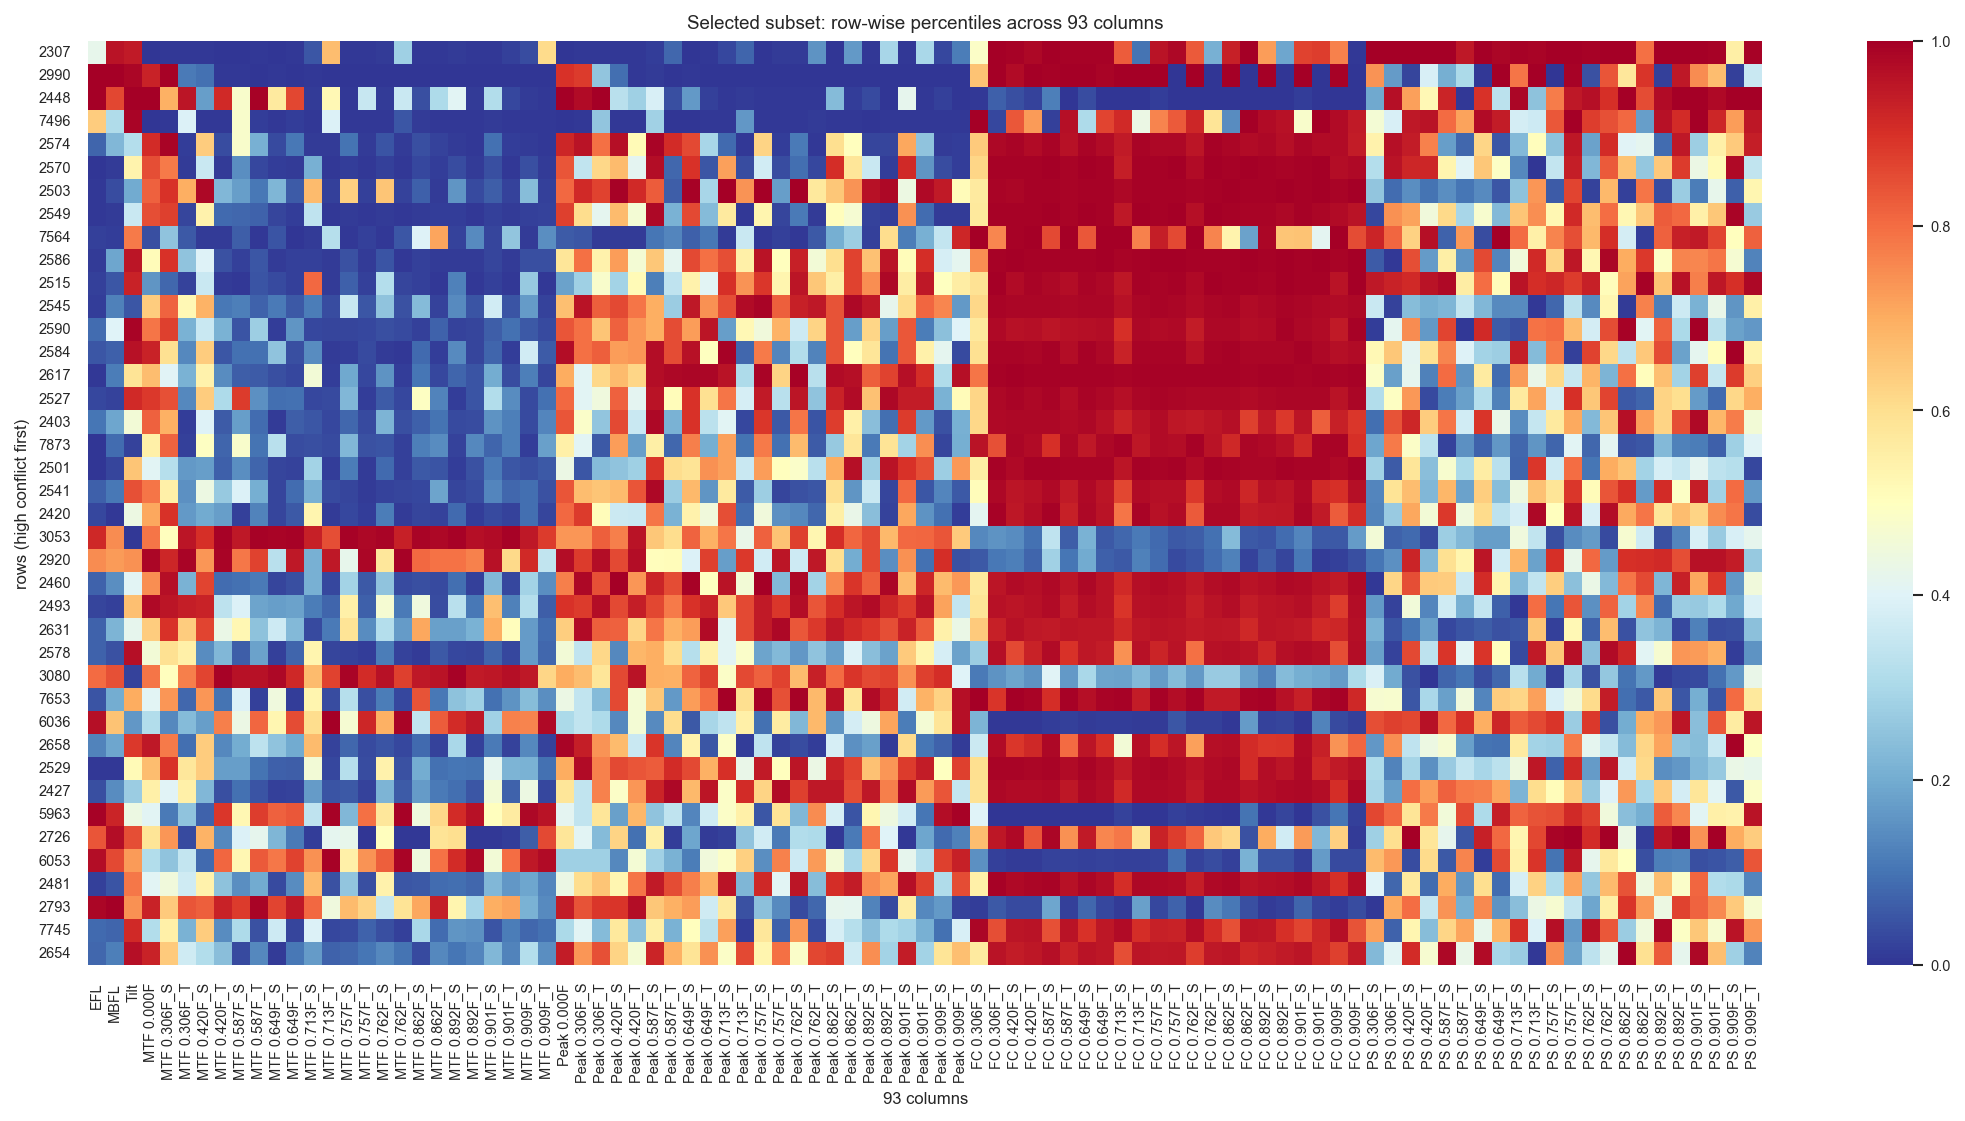

In [12]:
top_idx = row_conflict.sort_values(ascending=False).head(40).index
plt.figure(figsize=(18, 8))
sns.heatmap(U_sel.loc[top_idx, cols_93], cmap="RdYlBu_r", vmin=0, vmax=1)
plt.title("Selected subset: row-wise percentiles across 93 columns")
plt.xlabel("93 columns")
plt.ylabel("rows (high conflict first)")
plt.show()

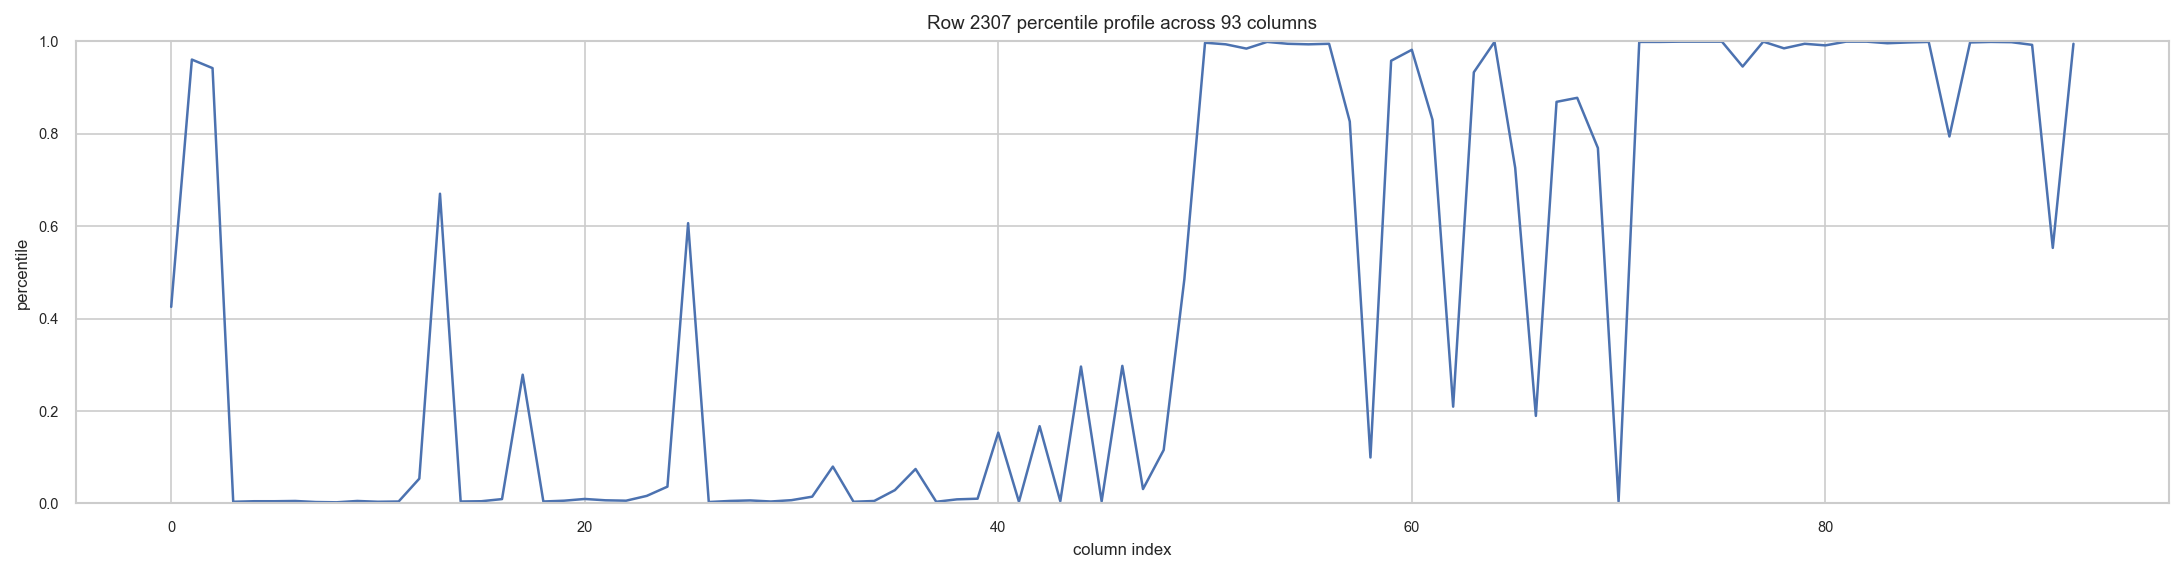

In [13]:
rid = row_conflict.idxmax()
prof = U_sel.loc[rid, cols_93]
plt.figure(figsize=(18, 4))
plt.plot(np.arange(len(cols_93)), prof.values, lw=1.2)
plt.ylim(0, 1)
plt.title(f"Row {rid} percentile profile across 93 columns")
plt.xlabel("column index")
plt.ylabel("percentile")
plt.show()

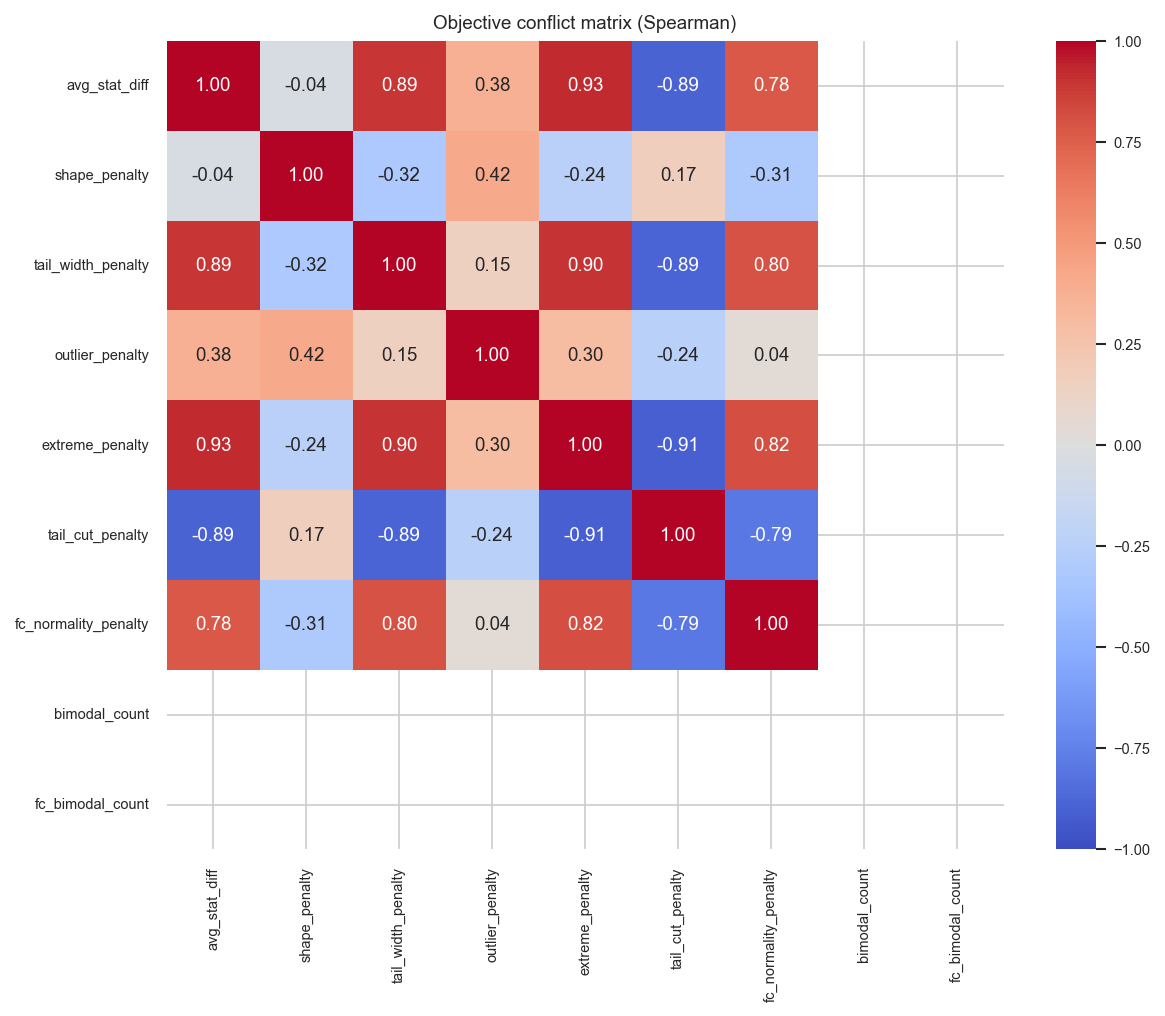

Most conflicting metric pairs (negative corr):
extreme_penalty     tail_cut_penalty       -0.909665
avg_stat_diff       tail_cut_penalty       -0.892844
tail_width_penalty  tail_cut_penalty       -0.885091
tail_cut_penalty    fc_normality_penalty   -0.792957
shape_penalty       tail_width_penalty     -0.317692
                    fc_normality_penalty   -0.306881
outlier_penalty     tail_cut_penalty       -0.243595
shape_penalty       extreme_penalty        -0.236290
avg_stat_diff       shape_penalty          -0.039575
outlier_penalty     fc_normality_penalty    0.039411
dtype: float64


In [14]:
metric_cols = [
"avg_stat_diff", "shape_penalty", "tail_width_penalty",
"outlier_penalty", "extreme_penalty", "tail_cut_penalty",
"fc_normality_penalty", "bimodal_count", "fc_bimodal_count"
]
M = history_df[metric_cols].copy()
corr = M.corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Objective conflict matrix (Spearman)")
plt.show()

pairs = (
corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
.stack()
.sort_values()
)
print("Most conflicting metric pairs (negative corr):")
print(pairs.head(10))

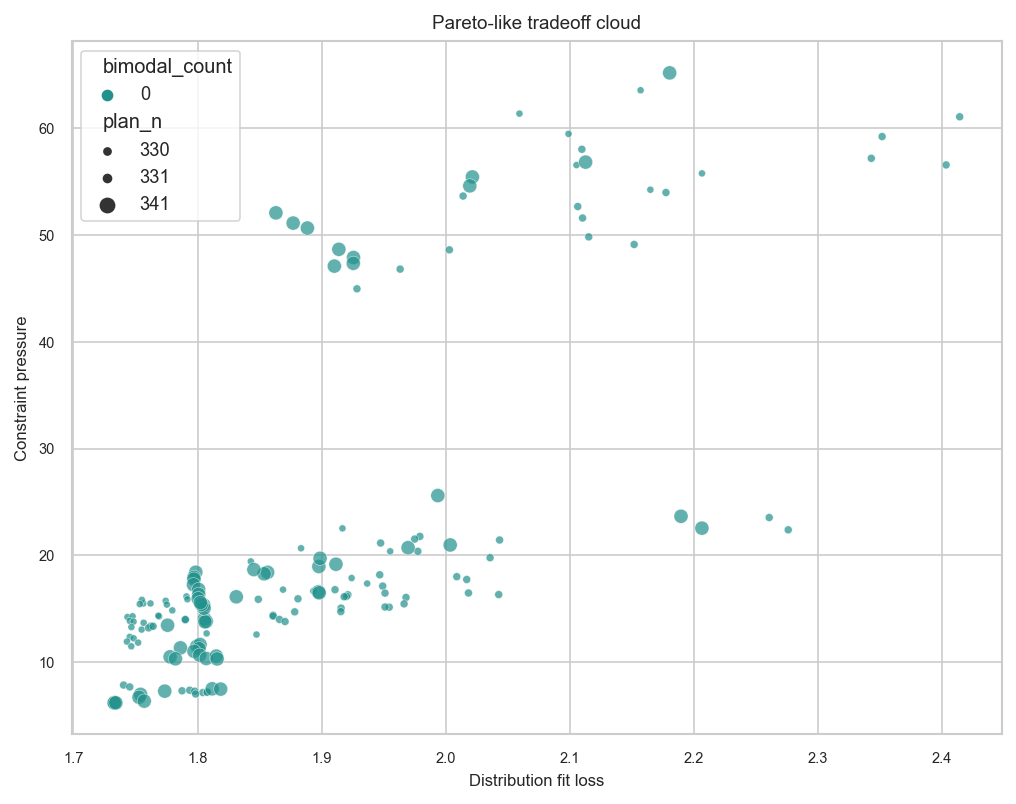

In [15]:
history_df = history_df.copy()
history_df["fit_loss"] = (
history_df["avg_stat_diff"] +
history_df["shape_penalty"] +
history_df["tail_width_penalty"]
)
history_df["constraint_loss"] = (
history_df["fc_normality_penalty"] +
5.0 * history_df["bimodal_count"] +
2.0 * history_df["tail_cut_hard_count"]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
data=history_df,
x="fit_loss",
y="constraint_loss",
hue="bimodal_count",
size="plan_n",
palette="viridis",
alpha=0.7
)
plt.title("Pareto-like tradeoff cloud")
plt.xlabel("Distribution fit loss")
plt.ylabel("Constraint pressure")
plt.show()